## 5.1 オッズ

### オッズは、ある事象が起こる確率を、その事象が起こらない確率で割ったもの

In [2]:
def Odds (p):
    return p / (1 - p)

def Probability(o):
    return o / (1 + o)

def Probability2(yes, no):
    return yes / (yes + no)


## 5.2 ベイズの定理をオッズの形式にする



事後オッズ(posterior odds)は事前オッズ(prior odds)に尤度の比をかけたものになる

クッキーの入った２つのボウルがある。ボウル１には30枚のバニラクッキー、10枚のチョコクッキーが、ボウル２にはそれぞれ20枚ずつのクッキーが入っている。どちらかのボウルをランダムに選び、目をづぶってクッキー1枚をランダムに選ぶ、そのクッキーがバニラだった時に、ボウル１だという確率はいくらだろう。オッズ形式で答えよ。

### 尤度
観測データ：バニラクッキーを引いた

ボウル、

In [3]:
# ボウル1
vanilla1 = 30
choco1 = 10

# ボウル2
vanilla2 = 20
choco2 = 20

# 事前確率
prior_h1 = 0.5
prior_h2 = 0.5

# 尤度
likelihood_h1 = vanilla1 / (vanilla1 + choco1)
likelihood_h2 = vanilla2 / (vanilla2 + choco2)

# 事前オッズ
prior_odds = prior_h1 / prior_h2

# 尤度比
likelihood_ratio = likelihood_h1 / likelihood_h2

# 事後オッズ
posterior_odds = prior_odds * likelihood_ratio

print(f"事前オッズ = {prior_odds:.2f}")
print(f"尤度比     = {likelihood_ratio:.2f}")
print(f"事後オッズ = {posterior_odds:.2f}")

print(f"\n事後オッズは {posterior_odds}:1")
print("整数比では 3:2")

事前オッズ = 1.00
尤度比     = 1.50
事後オッズ = 1.50

事後オッズは 1.5:1
整数比では 3:2


### 5.3 オリバーの血液型

犯罪現場に２人の血痕が残されていた。容疑者オリバーは、採血の結果、血液型はO型だった。2人の血痕は、O型（その地域で多い血液型、頻度60%）とAB型（珍しい型、頻度1%）と判明した。このデータは、オリバーがそのうちの１名であると言う命題を裏付ける証拠となるだろうか。



仮説H１：オリバーが現場に血痕を残した人物の1人とするならば、O型はオリバーのものなので、このデータの確率はランダムに選んだ1人がAB型である。→ 1%

仮説H２:オリバーが現場に血痕を残した人物ではないとするならば、ランダムに選んだ2人のうち1人がO型、かつもう1人がAB型になるので、最初に選んだ1人がO型、次に選んだ1人がAB型、あるいはその反対なので、
$ 2(0.6)(0.01) = 1.2 $ %

したがって、データの尤度は、オリバーが現場に血痕を残した人物の1人ではない方が、若干高くなり、オリバーが犯人ではないという確証となる。



### 5.4 加数



In [5]:
pmf_die = {i:1/6 for i in range(1, 7)}
print(f"PMF of a fair six-sided die: {pmf_die}")

PMF of a fair six-sided die: {1: 0.16666666666666666, 2: 0.16666666666666666, 3: 0.16666666666666666, 4: 0.16666666666666666, 5: 0.16666666666666666, 6: 0.16666666666666666}


In [13]:
from collections import Counter

pmf_die = Counter({i:1/6 for i in range(1,7)})
print(f"PMF of a fair six-sided die: {pmf_die}")

PMF of a fair six-sided die: Counter({1: 0.16666666666666666, 2: 0.16666666666666666, 3: 0.16666666666666666, 4: 0.16666666666666666, 5: 0.16666666666666666, 6: 0.16666666666666666})


In [14]:
from collections import defaultdict

def add_pmfs(pmf1, pmf2):
    result = defaultdict(float)
    for x1, p1 in pmf1.items():
        for x2, p2 in pmf2.items():
            new_value = x1 + x2
            new_prob = p1 * p2
            result[new_value] += new_prob
    return dict(result)

In [15]:
pmf_2dice = add_pmfs(pmf_die, pmf_die)
print(f"PMF of the sum of two dice: {pmf_2dice}")

PMF of the sum of two dice: {2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666669, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}


In [16]:
from collections import defaultdict

def add_pmfs(pmf1, pmf2):
    result = defaultdict(float)
    for x1, p1 in  pmf1.items():
        for x2, p2 in pmf2.items():
            new_value = x1 + x2
            new_prob = p1 * p2
            result[new_value] += new_prob
    return dict(result)

In [17]:


pmf_2dice = add_pmfs(pmf_die, pmf_die)

print(f"PMF of the sum of two dice: {pmf_2dice}")


PMF of the sum of two dice: {2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666669, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}


In [18]:
pmf_3dice = add_pmfs(pmf_2dice, pmf_die)

print(f"PMF of the sum of three dice: {pmf_3dice}")

PMF of the sum of three dice: {3: 0.004629629629629629, 4: 0.013888888888888888, 5: 0.027777777777777776, 6: 0.046296296296296294, 7: 0.06944444444444445, 8: 0.09722222222222222, 9: 0.11574074074074073, 10: 0.125, 11: 0.125, 12: 0.11574074074074074, 13: 0.09722222222222224, 14: 0.06944444444444445, 15: 0.046296296296296294, 16: 0.027777777777777776, 17: 0.013888888888888888, 18: 0.004629629629629629}


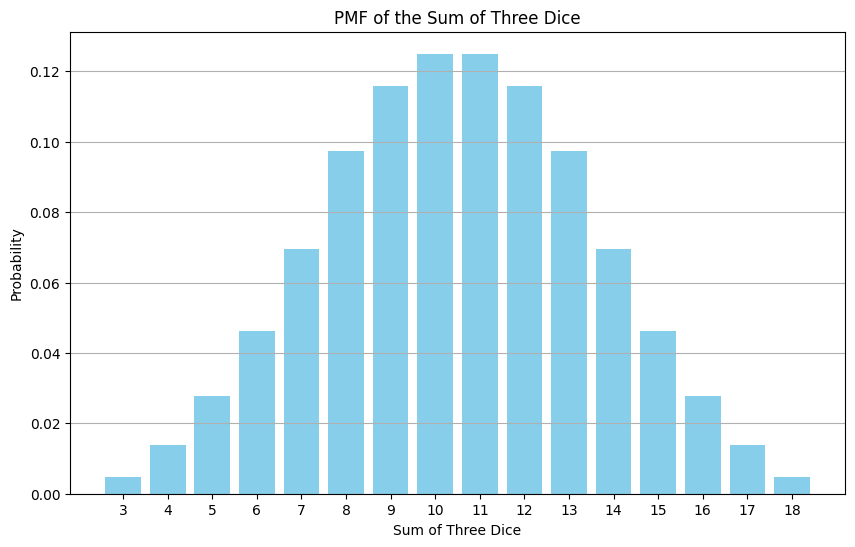

In [19]:
import matplotlib.pyplot as plt

x = sorted(pmf_3dice.keys())
y = [pmf_3dice[k] for k in x]

plt.figure(figsize=(10, 6))
plt.bar(x,y, color='skyblue')
plt.xlabel('Sum of Three Dice')
plt.ylabel('Probability')
plt.title('PMF of the Sum of Three Dice')
plt.xticks(x)
plt.grid(axis='y')



In [35]:
import random

sums = []

for _ in range(100000):
    total = (
        random.randint(1,6)
        + random.randint(1,6)
        + random.randint(1,6)
    )

    sums.append(total)

    

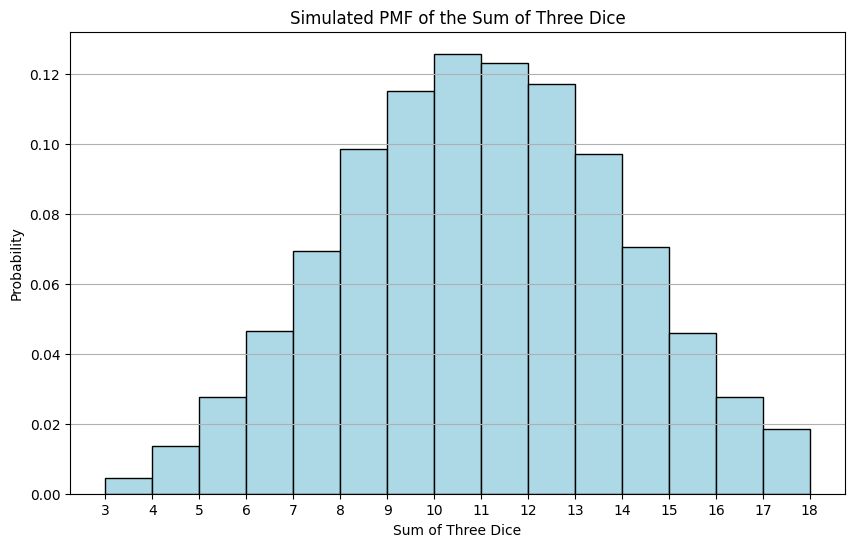

In [38]:
plt.figure(figsize=(10, 6))
plt.hist(sums, bins=range(3, 19), density=True, color='lightblue', edgecolor='black')
plt.xlabel('Sum of Three Dice')
plt.ylabel('Probability')
plt.title('Simulated PMF of the Sum of Three Dice')
plt.xticks(range(3, 19))
plt.grid(axis='y')  

### 5.5 最大値

最大値Mがx以下である確率は、６個の値が全てx以下である確率である。

$ p(M \le x) = p(X \le x)^6 $

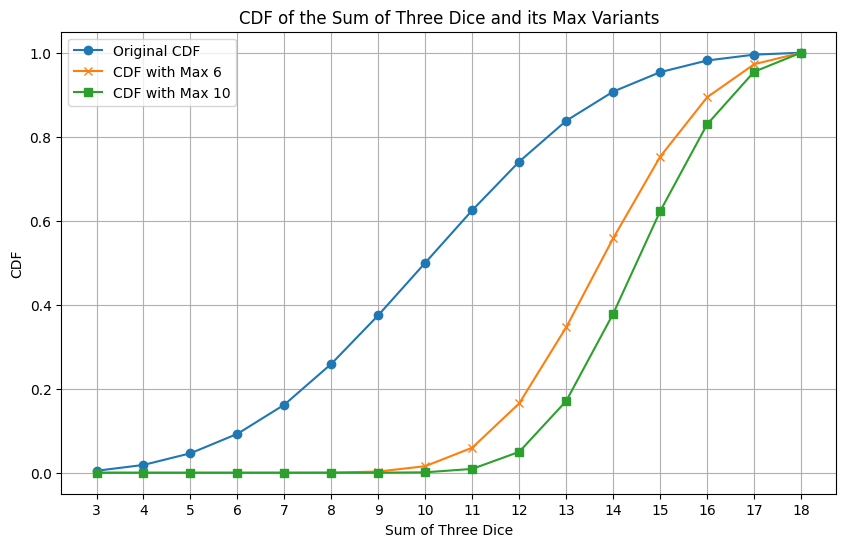

In [51]:
# pmfを足し合わせる関数

def add_pmf(pmf1, pmf2):
    result = defaultdict(float)

    for v1, p1 in pmf1.items():
        for v2, p2 in pmf2.items():
            new_value = v1 + v2
            new_prob = p1 * p2
            result[new_value] += new_prob

    return dict(result)

# 1個のサイコロのpmf
pmf_die = {i: 1/6 for i in range(1, 7)}

# 3個のサイコロのpmf
pmf_2dice = add_pmf(pmf_die, pmf_die)
pmf_3dice = add_pmf(pmf_2dice, pmf_die)

# cdfを作る
cdf = {}
running = 0

for x in sorted(pmf_3dice.keys()):
    running += pmf_3dice[x]
    cdf[x] = running

# 最大値のcdf
cdf_max6 = {}
cdf_max10 = {}

for x in sorted(cdf):
    cdf_max6[x] = cdf[x] ** 6
    cdf_max10[x] = cdf[x] ** 10

# グラフ用データ
x_values = sorted(pmf_3dice.keys())

y_original = [cdf[x] for x in x_values]
y_max6 = [cdf_max6[x] for x in x_values]

# グラフの描画
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_original, label='Original CDF', marker='o')
plt.plot(x_values, y_max6, label='CDF with Max 6', marker='x')
plt.plot(x_values, [cdf_max10[x] for x in x_values], label='CDF with Max 10', marker='s')
plt.xlabel('Sum of Three Dice')
plt.ylabel('CDF')
plt.title('CDF of the Sum of Three Dice and its Max Variants')
plt.xticks(x_values)
plt.grid()
plt.legend()
                

### 5.6 混合

複数のPMFを重み付きで足し合わせると、新しいPMFができる。

$ P(X) = \sum_d P(X|d) P(d) $

In [54]:
# PMFを作る




def make_die_pmf(sides):
    return {i: 1/sides for i in range(1, sides + 1)}

pmf_d4 = make_die_pmf(4)
pmf_d6 = make_die_pmf(6)
pmf_d8 = make_die_pmf(8) 
pmf_d12 = make_die_pmf(12)
pmf_d20 = make_die_pmf(20)

pmf_d4



{1: 0.25, 2: 0.25, 3: 0.25, 4: 0.25}

In [56]:
# 今後分布を作る

pmf_mix = defaultdict(float)

dice_pmfs = [pmf_d4, pmf_d6, pmf_d8, pmf_d12, pmf_d20]

for pmf in dice_pmfs:
    for value, prob in pmf.items():
        pmf_mix[value] += prob / 5  # 5種類のサイコロがあるので、確率を5で割る

# 確認

for value in sorted(pmf_mix):
    print(value, round(pmf_mix[value],4))        
    

1 0.135
2 0.135
3 0.135
4 0.135
5 0.085
6 0.085
7 0.0517
8 0.0517
9 0.0267
10 0.0267
11 0.0267
12 0.0267
13 0.01
14 0.01
15 0.01
16 0.01
17 0.01
18 0.01
19 0.01
20 0.01


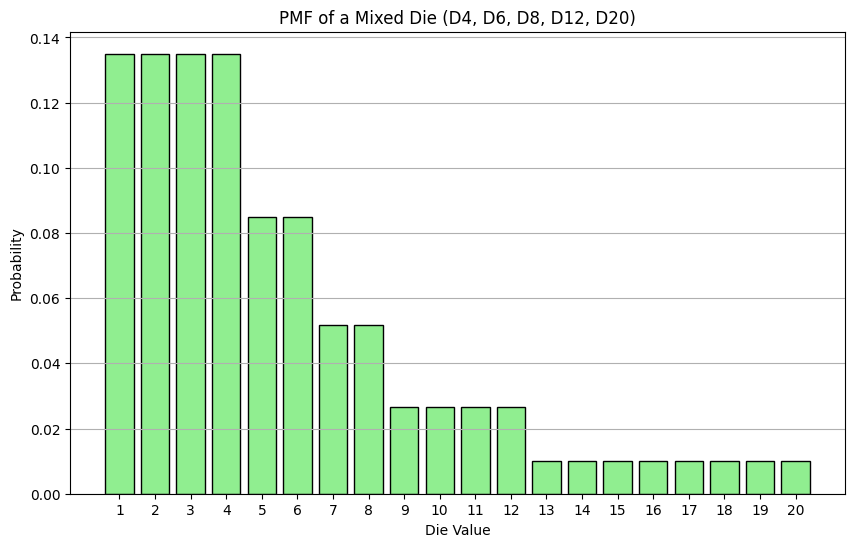

In [57]:
# グラフ作成

x = sorted(pmf_mix.keys())
y = [pmf_mix[k] for k in x]

plt.figure(figsize=(10, 6))
plt.bar(x, y, color='lightgreen', edgecolor='black')
plt.xlabel('Die Value')
plt.ylabel('Probability')
plt.title('PMF of a Mixed Die (D4, D6, D8, D12, D20)')
plt.xticks(x)
plt.grid(axis='y')